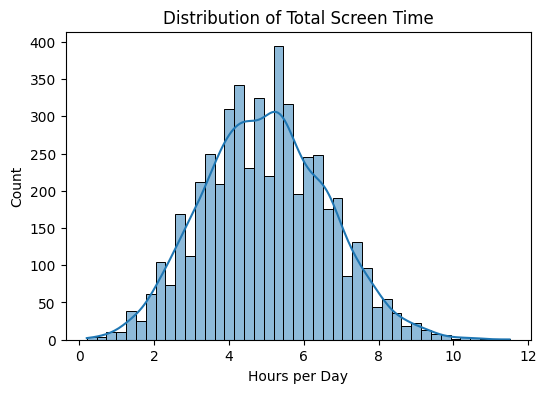

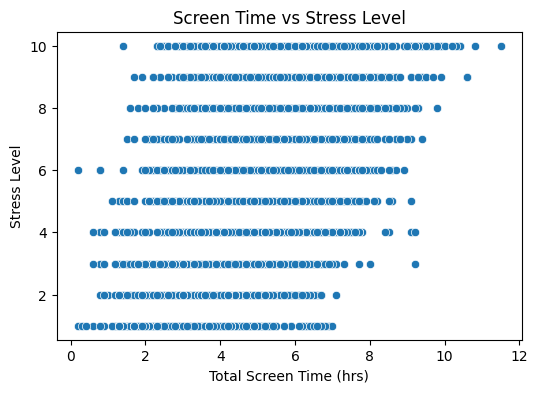

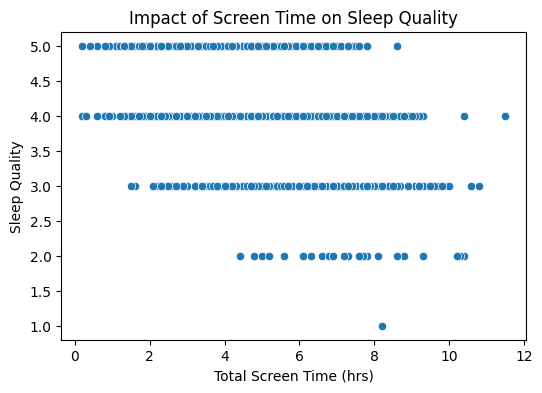

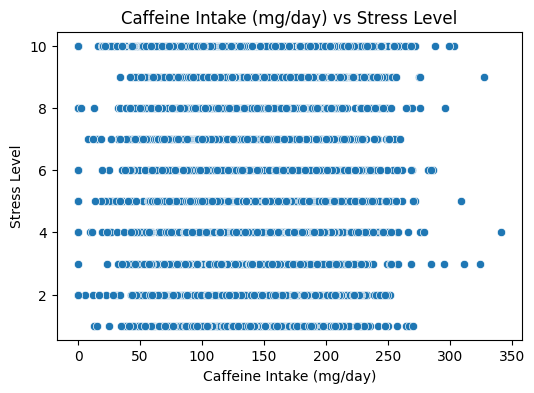

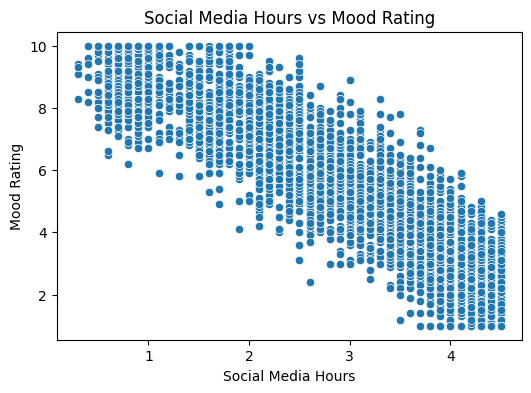

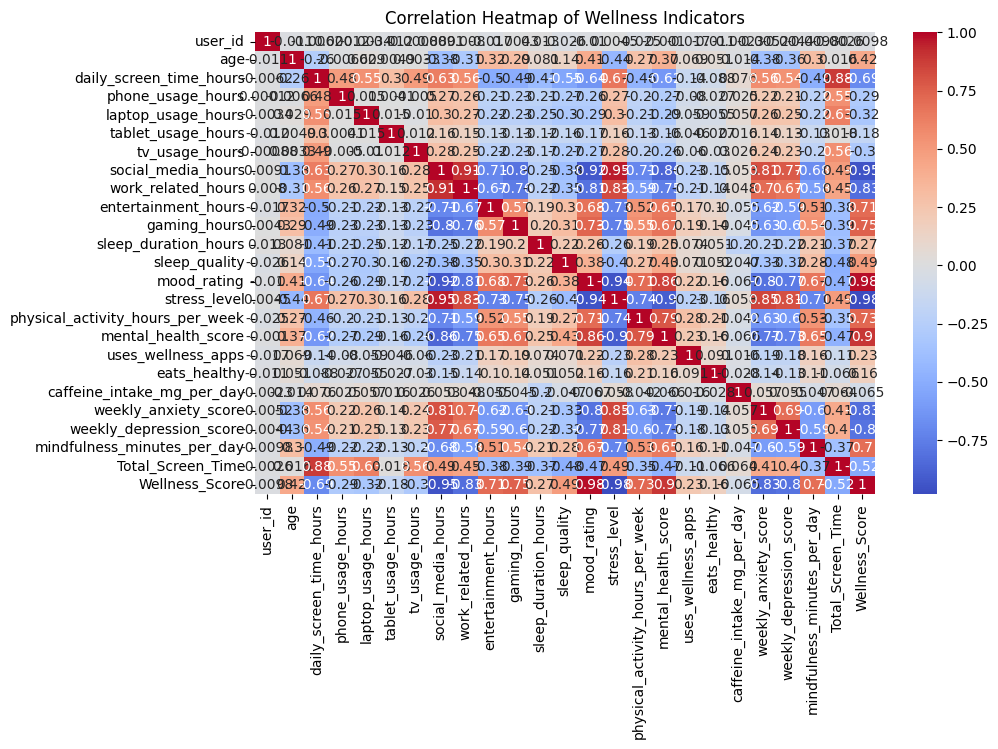

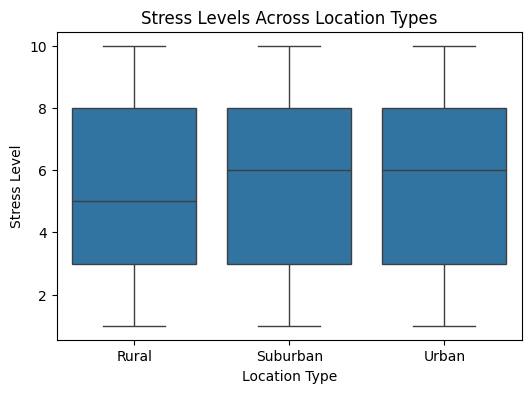

R^2 score: 0.6045
                            feature  coefficient
0                 Total_Screen_Time     0.755659
1  physical_activity_hours_per_week    -1.903951
2        caffeine_intake_mg_per_day     0.029762


In [2]:
# -----------------------------
# 1. Import Libraries
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# -----------------------------
# 2. Load Dataset
# -----------------------------
df = pd.read_csv("../dataSet/cia3/Tech_Use_Stress_Wellness.csv")

# -----------------------------
# 3. Basic Preprocessing & Cleaning
# -----------------------------
df.columns = df.columns.str.strip()

# Handle missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

# Convert categorical values if present
# Update to actual categorical column names in this dataset
categorical_cols = ['gender', 'location_type']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

# Feature Engineering
# Use the actual column names from the dataset
df["Total_Screen_Time"] = (
    df["phone_usage_hours"]
    + df["laptop_usage_hours"]
    + df["tv_usage_hours"]
)

# Use mood_rating (actual column name) instead of mood_score
df["Wellness_Score"] = (df["mood_rating"] + df["sleep_quality"]) - df["stress_level"]

# -----------------------------
# 4. Exploratory Data Analysis (Graphs)
# -----------------------------

# ---- Histogram for Screen Time ----
plt.figure(figsize=(6,4))
sns.histplot(df["Total_Screen_Time"], kde=True)
plt.title("Distribution of Total Screen Time")
plt.xlabel("Hours per Day")
plt.show()

# ---- Stress vs Screen Time ----
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["Total_Screen_Time"], y=df["stress_level"])
plt.title("Screen Time vs Stress Level")
plt.xlabel("Total Screen Time (hrs)")
plt.ylabel("Stress Level")
plt.show()

# ---- Sleep Quality vs Tech Usage ----
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["Total_Screen_Time"], y=df["sleep_quality"])
plt.title("Impact of Screen Time on Sleep Quality")
plt.xlabel("Total Screen Time (hrs)")
plt.ylabel("Sleep Quality")
plt.show()

# ---- Stress vs Caffeine Intake ----
plt.figure(figsize=(6,4))
# use caffeine_intake_mg_per_day (actual column)
sns.scatterplot(x=df["caffeine_intake_mg_per_day"], y=df["stress_level"])
plt.title("Caffeine Intake (mg/day) vs Stress Level")
plt.xlabel("Caffeine Intake (mg/day)")
plt.ylabel("Stress Level")
plt.show()

# ---- Mood vs Social Media ----
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["social_media_hours"], y=df["mood_rating"])
plt.title("Social Media Hours vs Mood Rating")
plt.xlabel("Social Media Hours")
plt.ylabel("Mood Rating")
plt.show()

# ---- Correlation Heatmap ----
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Wellness Indicators")
plt.show()

# ---- Boxplot: Stress across Living Environments (location_type) ----
plt.figure(figsize=(6,4))
sns.boxplot(x=df["location_type"], y=df["stress_level"])
plt.title("Stress Levels Across Location Types")
plt.xlabel("Location Type")
plt.ylabel("Stress Level")
plt.show()

# -----------------------------
# 5. Statistical Model (Regression)
# -----------------------------
# Use the corrected column names for features
X = df[["Total_Screen_Time", "physical_activity_hours_per_week", "caffeine_intake_mg_per_day"]]
y = df["stress_level"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

# Evaluate
r2 = r2_score(y_test, y_pred)
print(f"R^2 score: {r2:.4f}")

# Optional: show coefficients
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_
})
print(coef_df)


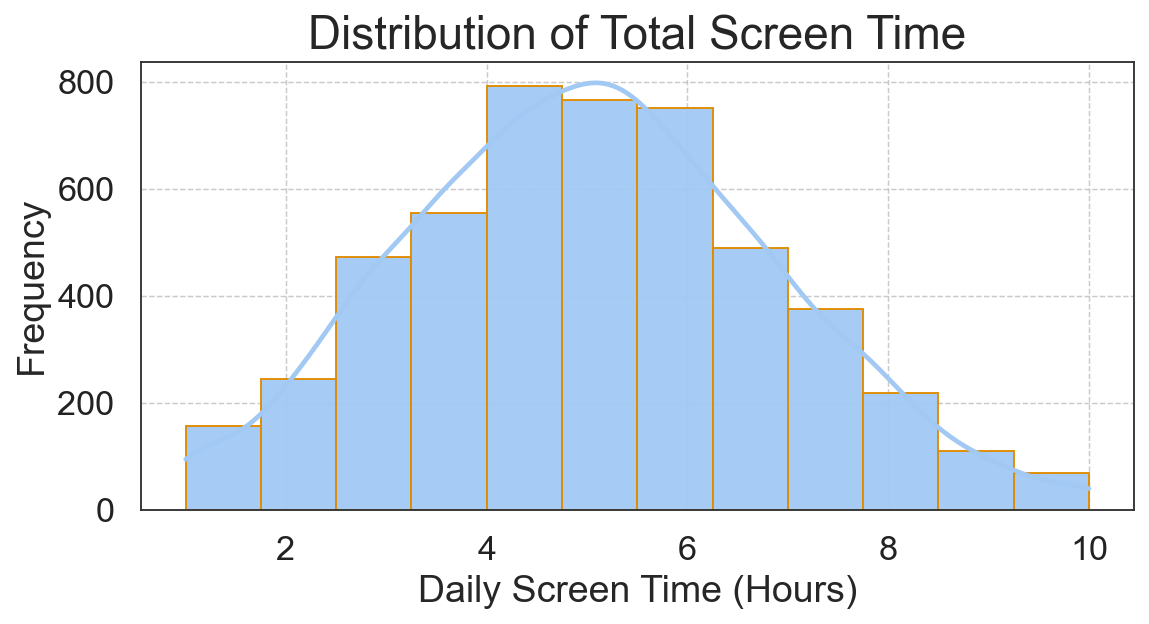

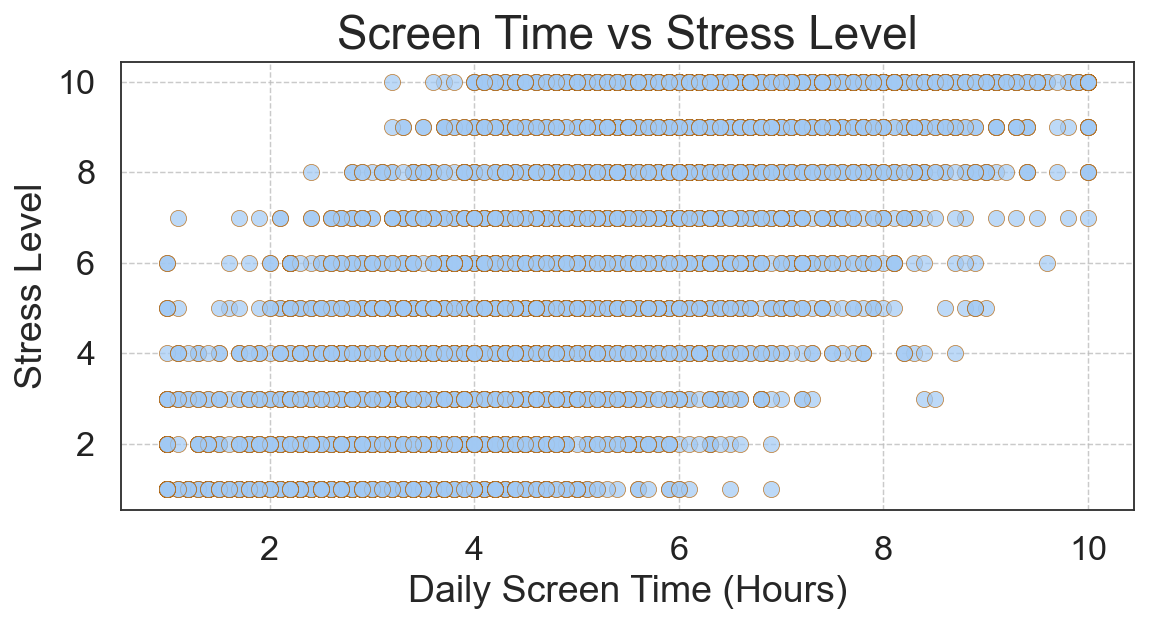

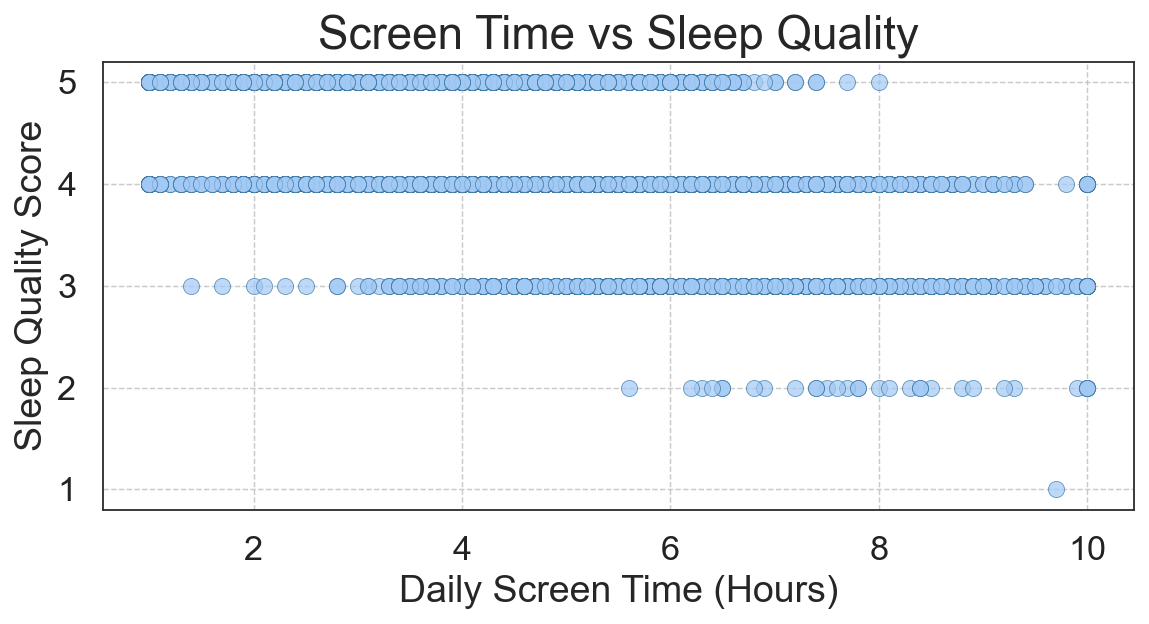

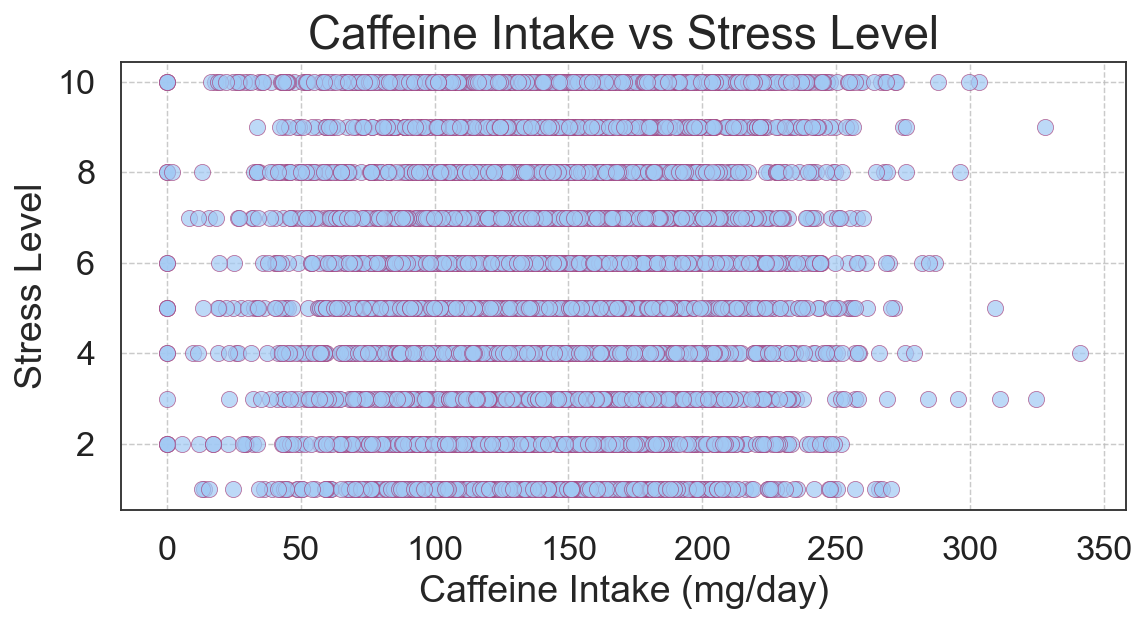

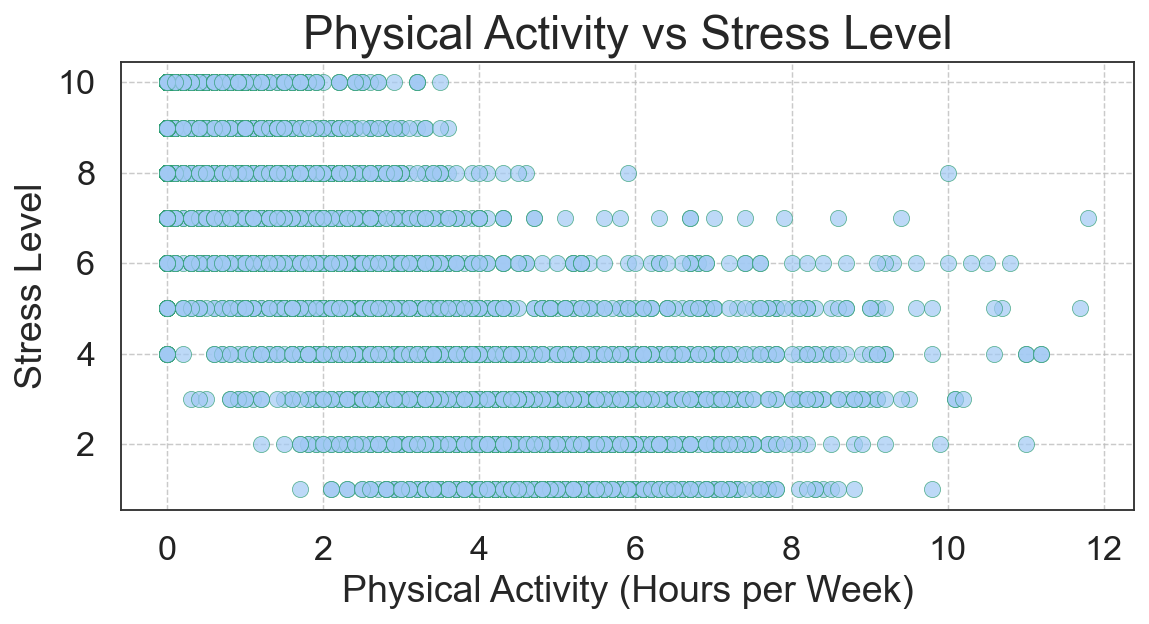

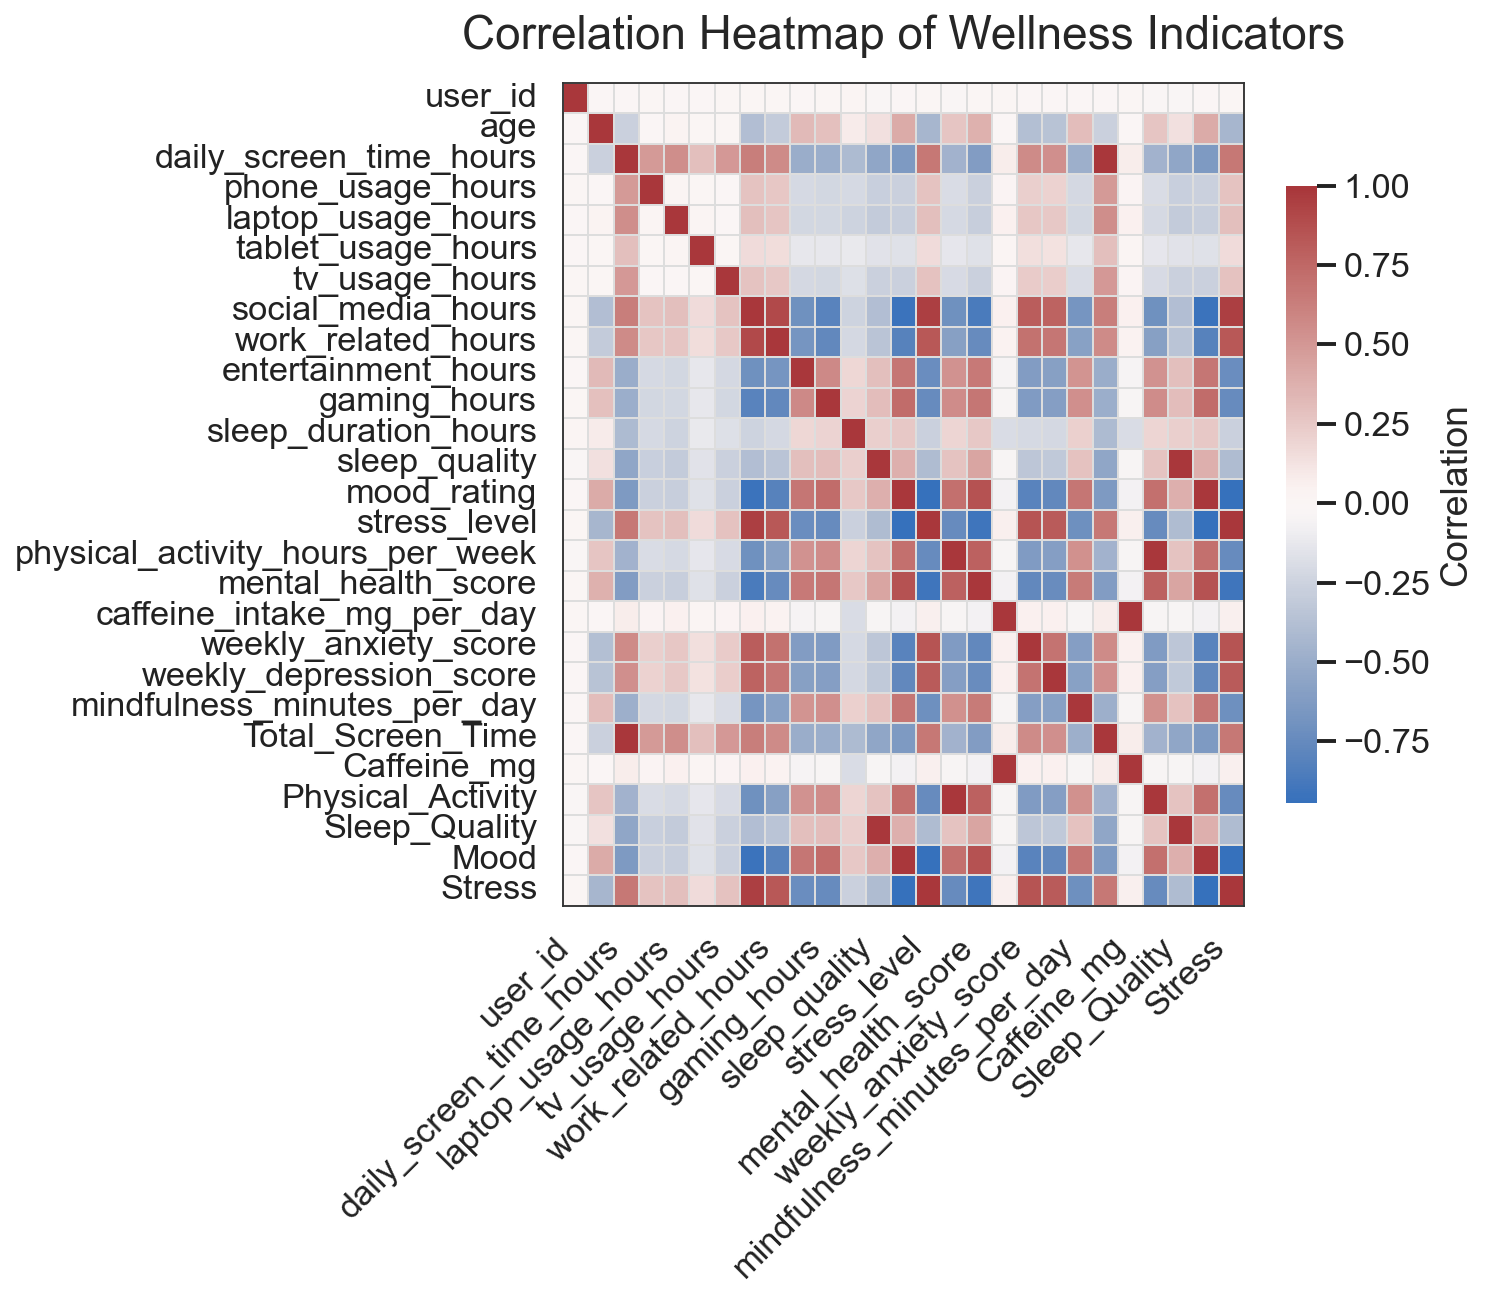

C:\Users\varun\AppData\Local\Temp\ipykernel_26528\1747040439.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="Location", y="Stress", data=df, palette="Set2", linewidth=1)


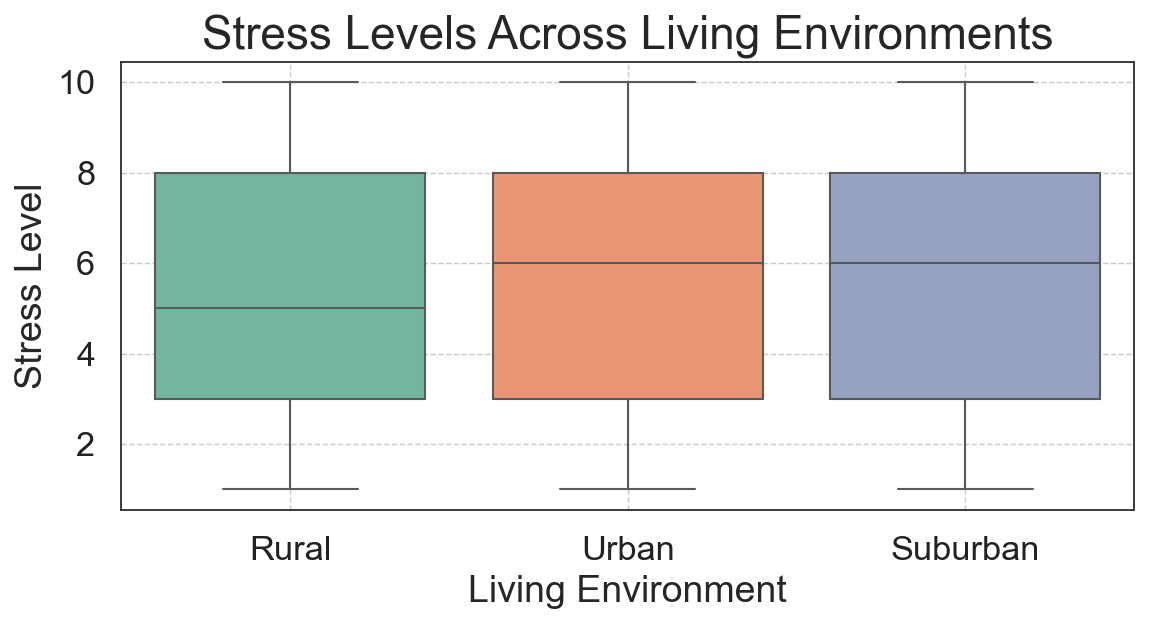

RuntimeError: `lowess=True` requires statsmodels, an optional dependency, to be installed.

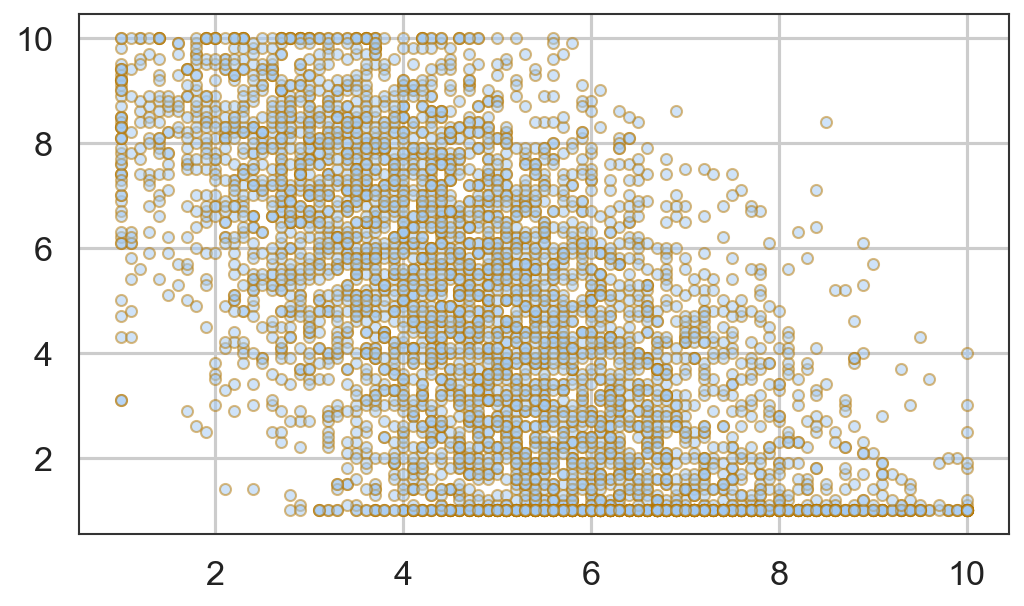

In [5]:
# Poster-ready colorful (light theme) visualizations using seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ---- Settings for a light, colorful, and clear style ----
sns.set_theme(style="whitegrid", palette="pastel")
sns.set_context("talk", rc={"axes.titlesize":22, "axes.labelsize":18, "legend.fontsize":14})
plt.rcParams.update({
    "figure.dpi":150,
    "axes.edgecolor":"#333333",
    "axes.linewidth":1.0,
    "xtick.color":"#222222",
    "ytick.color":"#222222",
})

OUT_DIR = "./figures/plots_poster"
os.makedirs(OUT_DIR, exist_ok=True)

# ---- Load data ----
df = pd.read_csv("../dataSet/cia3/Tech_Use_Stress_Wellness.csv")
# fill numeric NaNs with column mean (safe for plotting)
df = df.fillna(df.mean(numeric_only=True))

# Create friendly short names used below (guarded if column exists)
df["Total_Screen_Time"] = df.get("daily_screen_time_hours",
                                  df.get("phone_usage_hours", 0) + df.get("laptop_usage_hours",0) + df.get("tv_usage_hours",0))
df["Caffeine_mg"] = df.get("caffeine_intake_mg_per_day", df.get("caffeine_intake_mg_per_day", np.nan))
df["Physical_Activity"] = df.get("physical_activity_hours_per_week", np.nan)
df["Sleep_Quality"] = df.get("sleep_quality", np.nan)
df["Mood"] = df.get("mood_rating", np.nan)
df["Stress"] = df.get("stress_level", np.nan)
df["Location"] = df.get("location_type", "Unknown")

# helper for clean gridlines
def beautify_axes(ax):
    ax.grid(True, which='major', linestyle='--', linewidth=0.7, color='#BDBDBD', alpha=0.8)
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("#333333")
        spine.set_linewidth(0.9)

# ---- 1. Histogram — Total Screen Time ----
plt.figure(figsize=(8,4.5))
ax = sns.histplot(df["Total_Screen_Time"].dropna(), bins=12, kde=True, edgecolor="#e08b00",
                  linewidth=0.9, alpha=0.95)
ax.set_title("Distribution of Total Screen Time")
ax.set_xlabel("Daily Screen Time (Hours)")
ax.set_ylabel("Frequency")
beautify_axes(ax)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/hist_total_screen_time.png", bbox_inches="tight")
plt.show()

# ---- 2. Scatter — Screen Time vs Stress Level ----
plt.figure(figsize=(8,4.5))
ax = sns.scatterplot(x="Total_Screen_Time", y="Stress", data=df,
                     s=60, alpha=0.7, edgecolor="#b35f00", linewidth=0.4)
ax.set_title("Screen Time vs Stress Level")
ax.set_xlabel("Daily Screen Time (Hours)")
ax.set_ylabel("Stress Level")
beautify_axes(ax)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/scatter_screen_vs_stress.png", bbox_inches="tight")
plt.show()

# ---- 3. Scatter — Screen Time vs Sleep Quality ----
plt.figure(figsize=(8,4.5))
ax = sns.scatterplot(x="Total_Screen_Time", y="Sleep_Quality", data=df,
                     s=60, alpha=0.7, edgecolor="#2f6f9f", linewidth=0.4)
ax.set_title("Screen Time vs Sleep Quality")
ax.set_xlabel("Daily Screen Time (Hours)")
ax.set_ylabel("Sleep Quality Score")
beautify_axes(ax)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/scatter_screen_vs_sleep.png", bbox_inches="tight")
plt.show()

# ---- 4. Scatter — Caffeine Intake vs Stress ----
plt.figure(figsize=(8,4.5))
# if caffeine values are large, show a slightly compressed scatter for visual clarity (no transform applied)
ax = sns.scatterplot(x="Caffeine_mg", y="Stress", data=df, s=60, alpha=0.7, edgecolor="#a63d7a", linewidth=0.4)
ax.set_title("Caffeine Intake vs Stress Level")
ax.set_xlabel("Caffeine Intake (mg/day)")
ax.set_ylabel("Stress Level")
beautify_axes(ax)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/scatter_caffeine_vs_stress.png", bbox_inches="tight")
plt.show()

# ---- 5. Scatter — Physical Activity vs Stress ----
plt.figure(figsize=(8,4.5))
ax = sns.scatterplot(x="Physical_Activity", y="Stress", data=df, s=60, alpha=0.7, edgecolor="#2a9d6f", linewidth=0.4)
ax.set_title("Physical Activity vs Stress Level")
ax.set_xlabel("Physical Activity (Hours per Week)")
ax.set_ylabel("Stress Level")
beautify_axes(ax)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/scatter_activity_vs_stress.png", bbox_inches="tight")
plt.show()

# ---- 6. Correlation Heatmap ----
plt.figure(figsize=(10,9))
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()
# Use diverging cmap that is light-friendly and colorful
ax = sns.heatmap(corr, cmap="vlag", center=0, annot=False, linewidths=0.8,
                 linecolor="#DDDDDD", cbar_kws={"shrink":0.75, "label":"Correlation"})
ax.set_title("Correlation Heatmap of Wellness Indicators", pad=16)
# rotate tick labels for poster readability
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
beautify_axes(ax)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/heatmap_correlation.png", bbox_inches="tight")
plt.show()

# ---- 7. Boxplot — Stress Across Living Environments ----
plt.figure(figsize=(8,4.5))
ax = sns.boxplot(x="Location", y="Stress", data=df, palette="Set2", linewidth=1)
ax.set_title("Stress Levels Across Living Environments")
ax.set_xlabel("Living Environment")
ax.set_ylabel("Stress Level")
beautify_axes(ax)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/boxplot_location_stress.png", bbox_inches="tight")
plt.show()

# ---- 8. Line Chart — Mood vs Screen Time (smoothed trend) ----
# Use local regression (lowess) via seaborn's regplot with lowess=True for smooth trend
plt.figure(figsize=(8,4.5))
ax = sns.regplot(x="Total_Screen_Time", y="Mood", data=df, scatter_kws={"s":28, "alpha":0.5, "edgecolor":"#b77700"},
                 line_kws={"color":"#e08b00", "linewidth":2.2}, lowess=True)
ax.set_title("Mood Trend Across Screen Time")
ax.set_xlabel("Daily Screen Time (Hours)")
ax.set_ylabel("Mood Rating")
beautify_axes(ax)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/line_mood_vs_screen_trend.png", bbox_inches="tight")
plt.show()

# ---- 9. Bar Chart — Average Stress by Screen Time Category ----
plt.figure(figsize=(8,4.5))
df["screen_cat"] = pd.cut(df["Total_Screen_Time"].fillna(0),
                          bins=[-0.1,2,4,6,8,100],
                          labels=["0–2 hrs","2–4 hrs","4–6 hrs","6–8 hrs","8+ hrs"])
avg_stress = df.groupby("screen_cat")["Stress"].mean().reindex(["0–2 hrs","2–4 hrs","4–6 hrs","6–8 hrs","8+ hrs"])
ax = sns.barplot(x=avg_stress.index, y=avg_stress.values, palette="pastel", edgecolor="#333333")
ax.set_title("Average Stress by Screen Time Category")
ax.set_xlabel("Screen Time Category")
ax.set_ylabel("Average Stress Level")
beautify_axes(ax)
# show numeric values above bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, color="#222222", xytext=(0,6), textcoords='offset points')
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/bar_avg_stress_by_screencat.png", bbox_inches="tight")
plt.show()

print(f"All plots saved to: {OUT_DIR}")


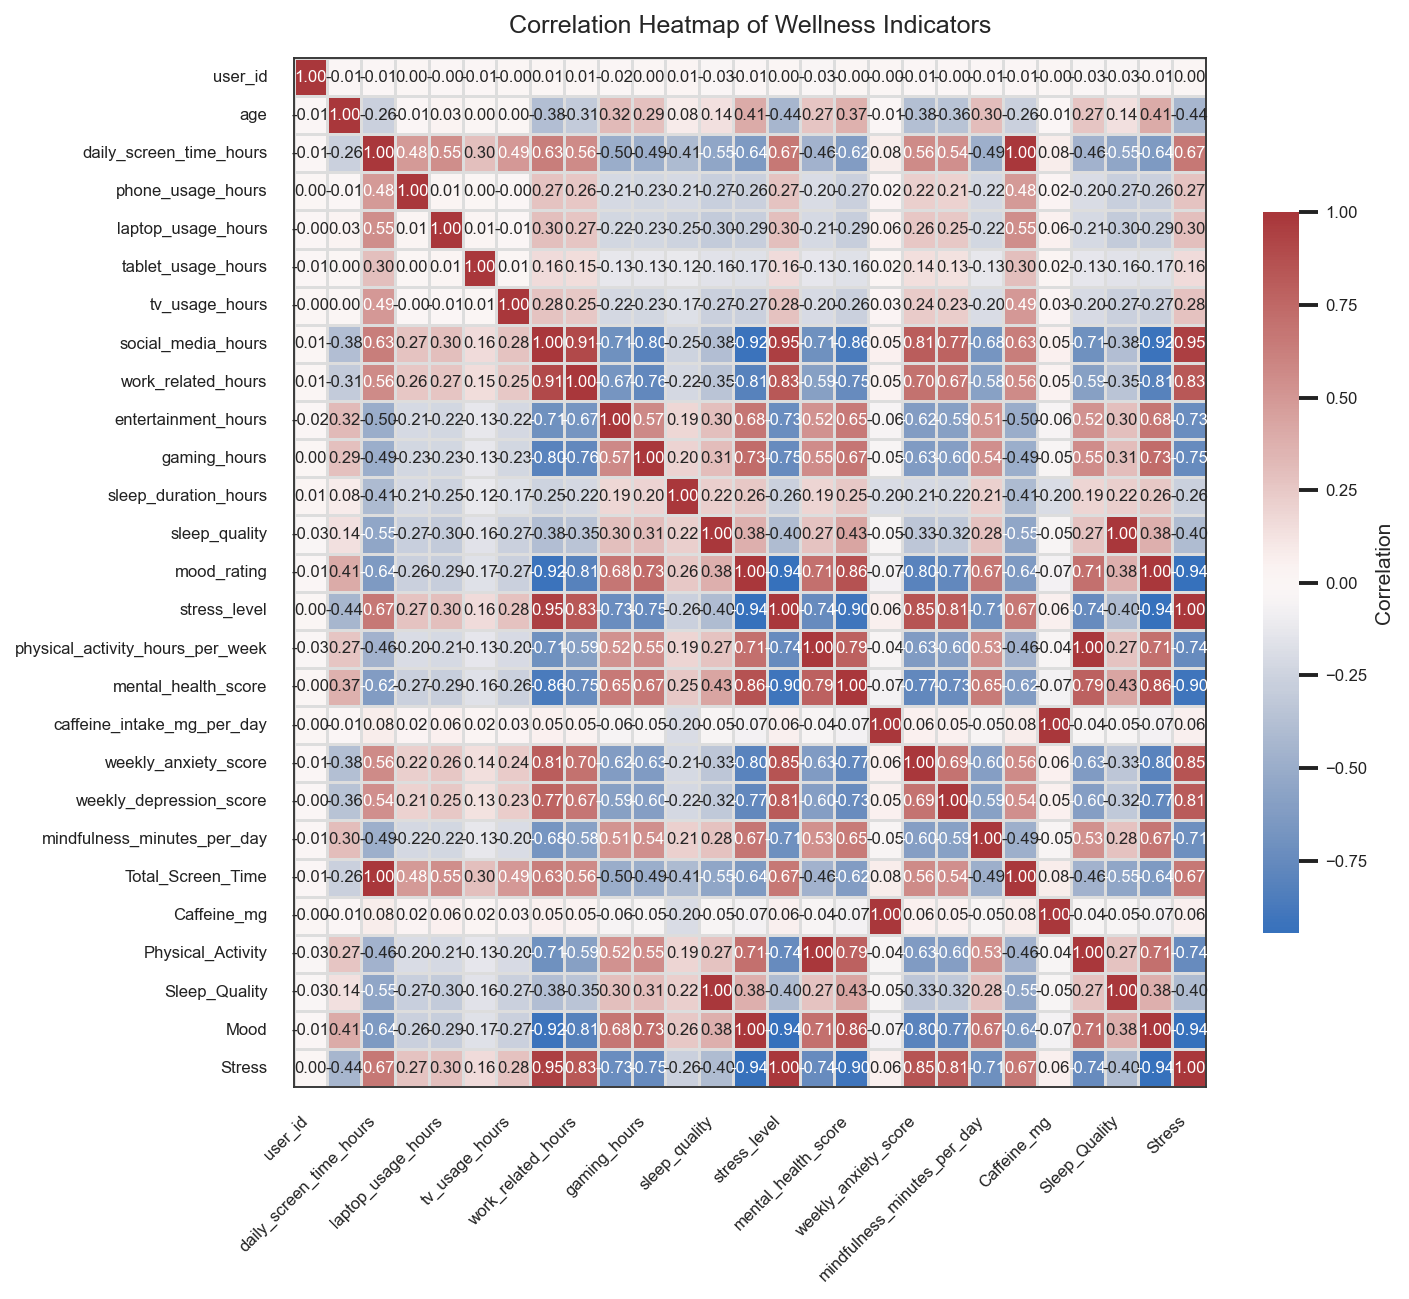

In [6]:
# Smaller-text correlation heatmap (uses existing `corr`, `num_cols`, `OUT_DIR`, and `beautify_axes` if present)
try:
    corr_df = corr
except NameError:
    corr_df = df[num_cols].corr()

plt.figure(figsize=(10,9))
ax = sns.heatmap(
    corr_df,
    cmap="vlag",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"fontsize":8},
    linewidths=0.6,
    linecolor="#DDDDDD",
    cbar_kws={"shrink":0.7, "label":"Correlation"}
)

# smaller title and tick labels
ax.set_title("Correlation Heatmap of Wellness Indicators", fontsize=12, pad=12)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)

# keep the same axis styling if beautify_axes exists
try:
    beautify_axes(ax)
except NameError:
    ax.grid(True, which='major', linestyle='--', linewidth=0.7, color='#BDBDBD', alpha=0.8)
    ax.set_facecolor('white')

# adjust colorbar tick label size
try:
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=8)
    cbar.set_label("Correlation", fontsize=10)
except Exception:
    pass

plt.tight_layout()
os.makedirs(OUT_DIR, exist_ok=True)
plt.savefig(f"{OUT_DIR}/heatmap_correlation_smalltext.png", bbox_inches="tight")
plt.show()

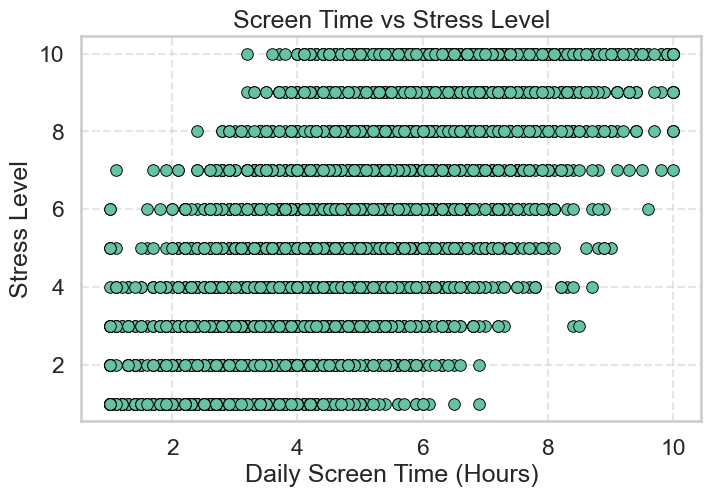

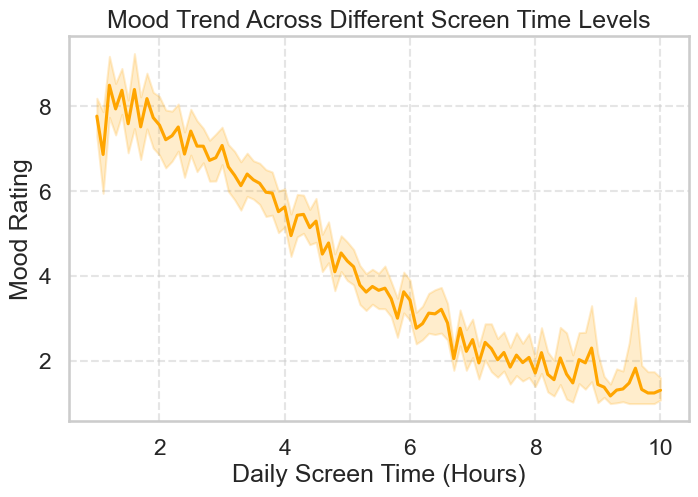

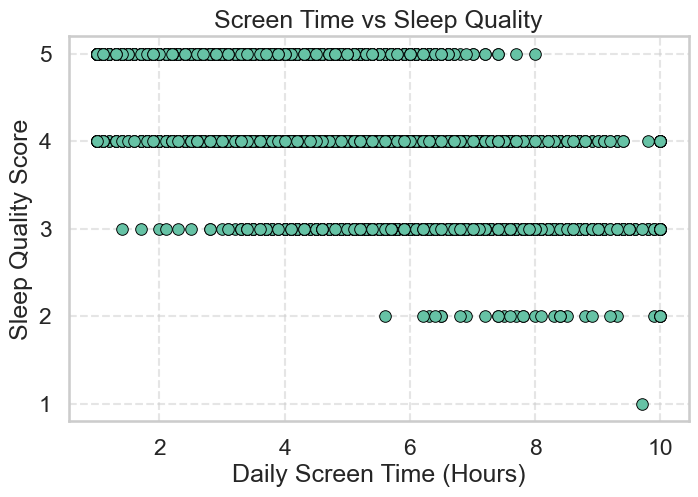

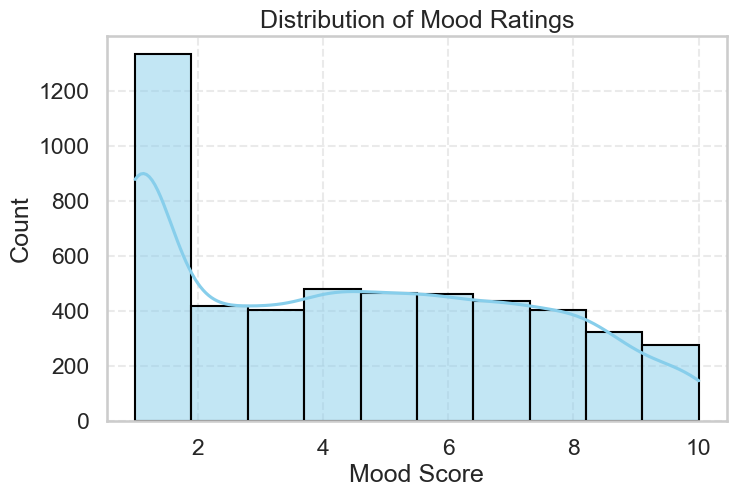

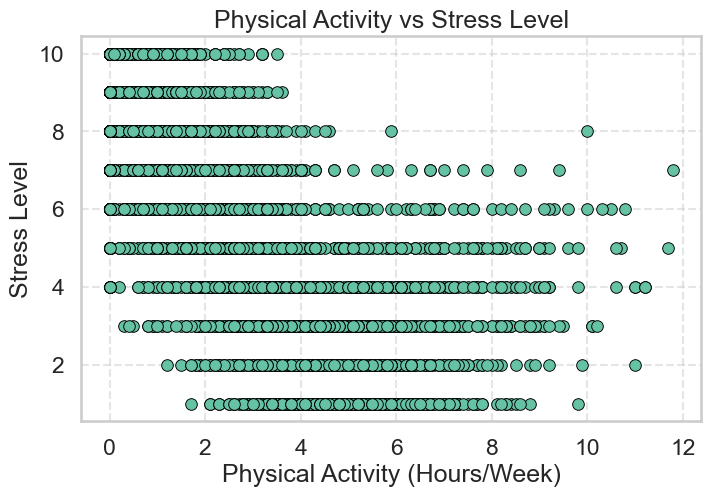

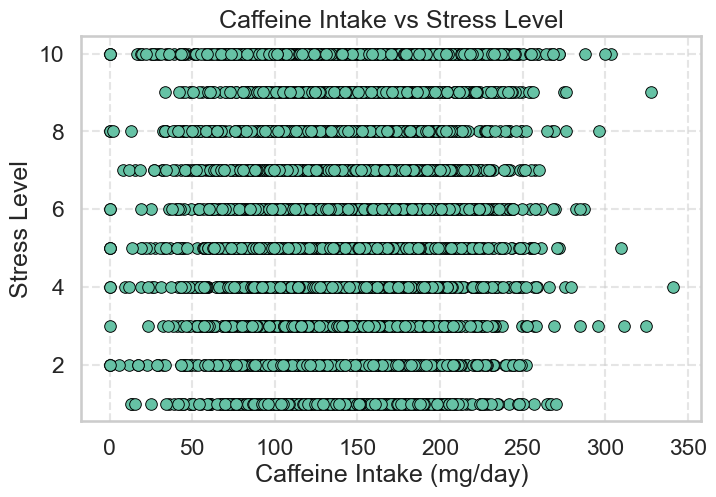

C:\Users\varun\AppData\Local\Temp\ipykernel_23688\2890806068.py:111: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Location", y="Stress", data=df, palette="Set3")


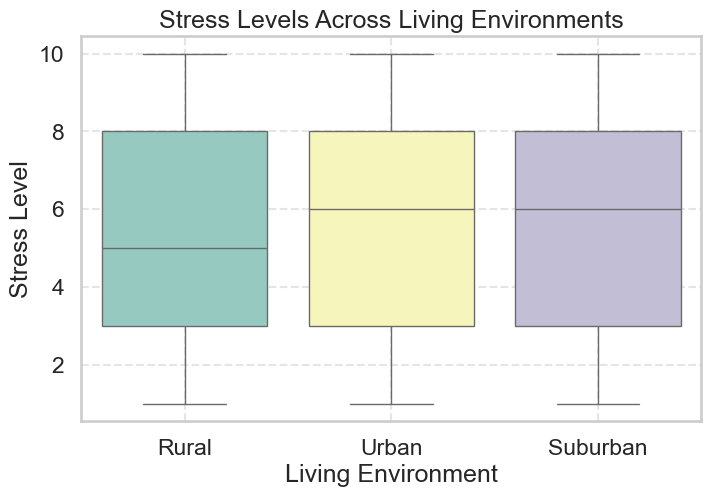

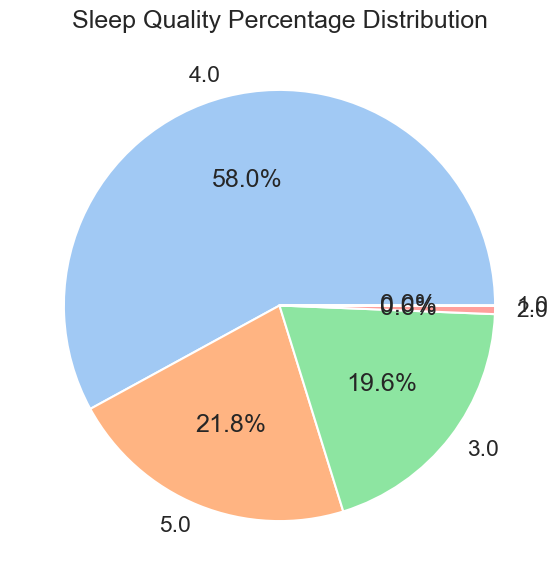

C:\Users\varun\AppData\Local\Temp\ipykernel_23688\2890806068.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="screen_cat", y="Stress", data=df, palette="viridis")


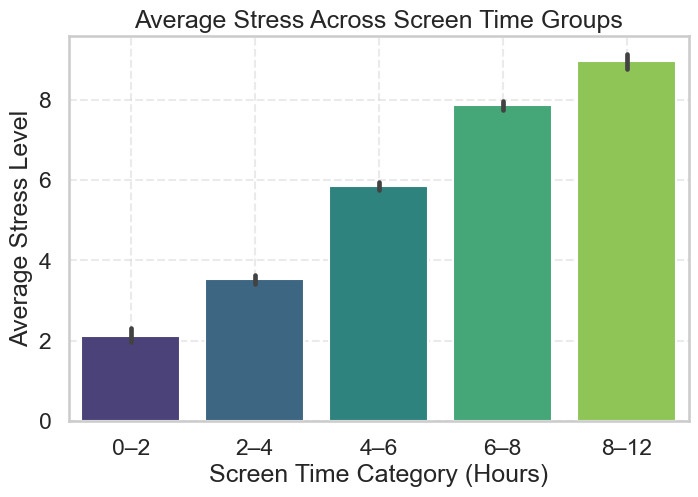

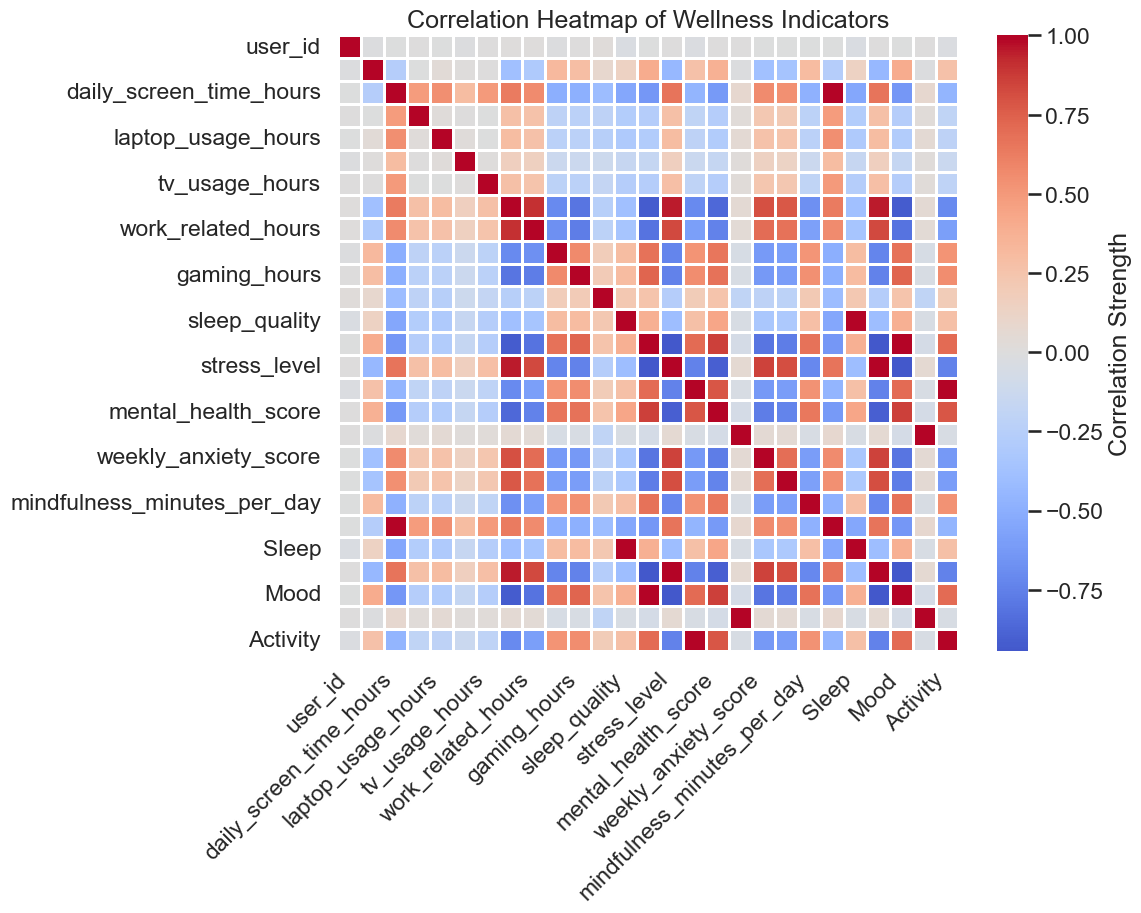

In [1]:
# -----------------------------------------------
# POSTER-VERSION: Clean, colorful, light-themed graphs
# -----------------------------------------------
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("../dataSet/cia3/Tech_Use_Stress_Wellness.csv")
df = df.fillna(df.mean(numeric_only=True))

# Light theme + pastel colors
sns.set_theme(style="whitegrid", palette="Set2")
sns.set_context("talk")

# Shorter aliases
df["Screen"] = df["daily_screen_time_hours"]
df["Sleep"] = df["sleep_quality"]
df["Stress"] = df["stress_level"]
df["Mood"] = df["mood_rating"]
df["Caffeine"] = df["caffeine_intake_mg_per_day"]
df["Activity"] = df["physical_activity_hours_per_week"]
df["Location"] = df["location_type"]


# ================================
# PROBLEM STATEMENT 1
# Impact of screen time on stress & wellness
# ================================

# 1) SCATTER – Screen Time vs Stress
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Screen", y="Stress", s=70, edgecolor="black")
plt.title("Screen Time vs Stress Level")
plt.xlabel("Daily Screen Time (Hours)")
plt.ylabel("Stress Level")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()
# Caption: "Higher screen time corresponds with gradual rise in stress levels."

# 2) LINE CHART – Screen Time vs Average Mood
plt.figure(figsize=(8,5))
sns.lineplot(x=df["Screen"], y=df["Mood"], color="orange")
plt.title("Mood Trend Across Different Screen Time Levels")
plt.xlabel("Daily Screen Time (Hours)")
plt.ylabel("Mood Rating")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()
# Caption: "Mood decreases slightly as screen time increases across users."


# ================================
# PROBLEM STATEMENT 2
# Tech usage patterns & sleep quality + mood
# ================================

# 3) SCATTER – Screen Time vs Sleep Quality
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Screen", y="Sleep", s=70, edgecolor="black")
plt.title("Screen Time vs Sleep Quality")
plt.xlabel("Daily Screen Time (Hours)")
plt.ylabel("Sleep Quality Score")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()
# Caption: "Increasing screen exposure is linked to poorer overall sleep quality."

# 4) HISTOGRAM – Mood Rating Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Mood"], bins=10, kde=True, color="skyblue", edgecolor="black")
plt.title("Distribution of Mood Ratings")
plt.xlabel("Mood Score")
plt.ylabel("Count")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()
# Caption: "Most users report balanced mood levels with slight variation."


# ================================
# PROBLEM STATEMENT 3
# Physical activity, caffeine & stress
# ================================

# 5) SCATTER – Activity vs Stress
plt.figure(figsize=(8,5))
sns.scatterplot(x="Activity", y="Stress", data=df, s=70, edgecolor="black")
plt.title("Physical Activity vs Stress Level")
plt.xlabel("Physical Activity (Hours/Week)")
plt.ylabel("Stress Level")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()
# Caption: "Higher physical activity correlates with noticeably lower stress."

# 6) SCATTER – Caffeine vs Stress
plt.figure(figsize=(8,5))
sns.scatterplot(x="Caffeine", y="Stress", data=df, s=70, edgecolor="black")
plt.title("Caffeine Intake vs Stress Level")
plt.xlabel("Caffeine Intake (mg/day)")
plt.ylabel("Stress Level")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()
# Caption: "Caffeine consumption increases stress especially at higher intake ranges."


# ================================
# ADDITIONAL REQUIRED GRAPHS
# ================================

# 7) BOX PLOT – Stress by Living Environment
plt.figure(figsize=(8,5))
sns.boxplot(x="Location", y="Stress", data=df, palette="Set3")
plt.title("Stress Levels Across Living Environments")
plt.xlabel("Living Environment")
plt.ylabel("Stress Level")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()
# Caption: "Stress varies between living spaces, indicating environmental influence."

# 8) PIE CHART – Sleep Quality Categories
sleep_counts = df["Sleep"].value_counts()
plt.figure(figsize=(7,7))
plt.pie(sleep_counts, labels=sleep_counts.index,
        autopct="%1.1f%%", colors=sns.color_palette("pastel"))
plt.title("Sleep Quality Percentage Distribution")
plt.show()
# Caption: "Majority of users fall in average sleep quality ranges."

# 9) BAR CHART – Average Stress by Screen Time Category
df["screen_cat"] = pd.cut(df["Screen"], bins=[0,2,4,6,8,12],
                          labels=["0–2","2–4","4–6","6–8","8–12"])
plt.figure(figsize=(8,5))
sns.barplot(x="screen_cat", y="Stress", data=df, palette="viridis")
plt.title("Average Stress Across Screen Time Groups")
plt.xlabel("Screen Time Category (Hours)")
plt.ylabel("Average Stress Level")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()
# Caption: "Stress rises significantly in higher daily screen-time groups."


# ================================
# HEATMAP (no text inside boxes)
# ================================
plt.figure(figsize=(10,8))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, cmap="coolwarm", center=0, cbar_kws={"label": "Correlation Strength"},
            linewidths=0.8, linecolor="white", annot=False)
plt.title("Correlation Heatmap of Wellness Indicators")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()
# Caption: "Correlation map highlights relationships without cluttering numeric labels."


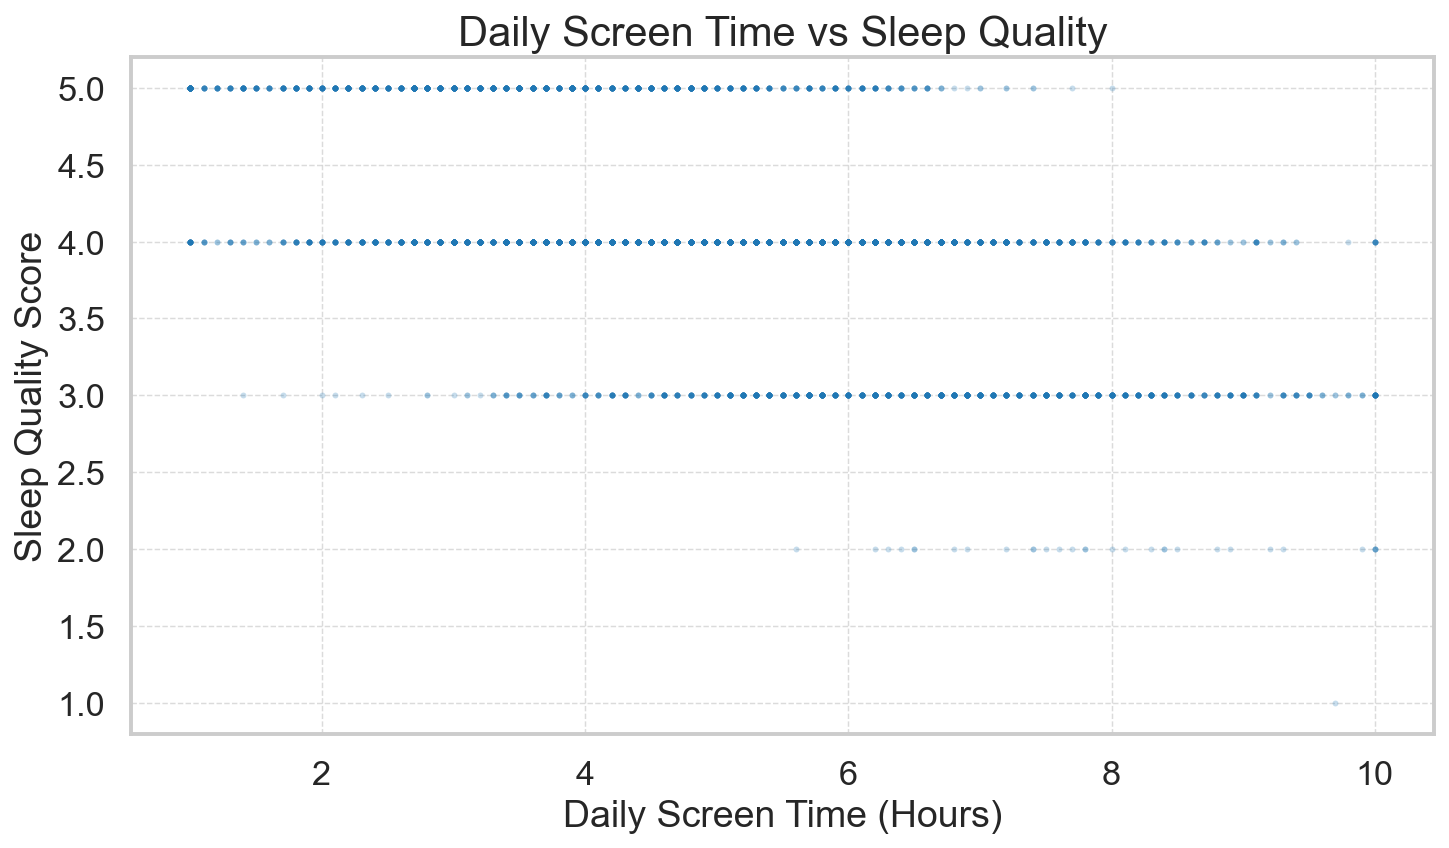

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
df = pd.read_csv("../dataSet/cia3/Tech_Use_Stress_Wellness.csv")
df["Screen"] = df["daily_screen_time_hours"]
df["Sleep"] = df["sleep_quality"]

# Light theme
sns.set_theme(style="whitegrid")
sns.set_context("talk")

plt.figure(figsize=(10,6))

# Scatter plot with tiny dots + high transparency
plt.scatter(
    df["Screen"],
    df["Sleep"],
    s=8,                # ***very small dots***
    alpha=0.25,         # transparency to show density
    c="#1f77b4",        # soft blue color
    linewidths=0        # no edge
)

plt.title("Daily Screen Time vs Sleep Quality", fontsize=20)
plt.xlabel("Daily Screen Time (Hours)", fontsize=18)
plt.ylabel("Sleep Quality Score", fontsize=18)

# High-visibility clean grid
plt.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)

plt.tight_layout()
plt.show()


C:\Users\varun\AppData\Local\Temp\ipykernel_26528\3287416853.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("screen_group")[["Stress", "Sleep", "Mood"]].mean().reset_index()


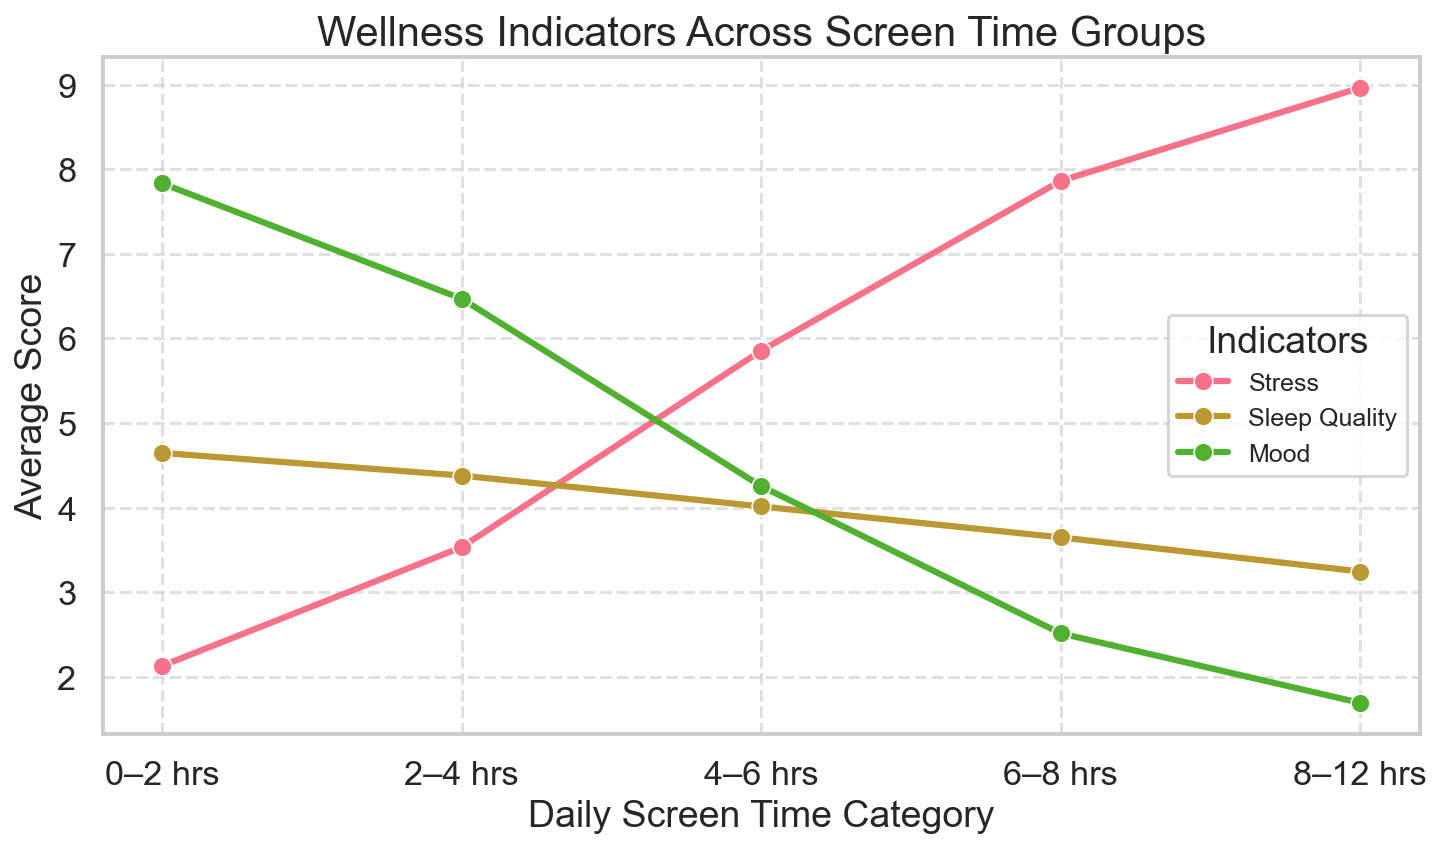

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("../dataSet/cia3/Tech_Use_Stress_Wellness.csv")

# Preprocess
df["Screen"] = df["daily_screen_time_hours"]
df["Sleep"] = df["sleep_quality"]
df["Stress"] = df["stress_level"]
df["Mood"] = df["mood_rating"]

# Create screen time categories for trend analysis
df["screen_group"] = pd.cut(df["Screen"],
                            bins=[0,2,4,6,8,12],
                            labels=["0–2 hrs","2–4 hrs","4–6 hrs","6–8 hrs","8–12 hrs"])

# Compute mean values for each category
grouped = df.groupby("screen_group")[["Stress", "Sleep", "Mood"]].mean().reset_index()

# Light colorful theme
sns.set_theme(style="whitegrid", palette="husl")
sns.set_context("talk")

plt.figure(figsize=(10,6))

# Create line chart
sns.lineplot(x="screen_group", y="Stress", data=grouped, marker="o", linewidth=3, label="Stress")
sns.lineplot(x="screen_group", y="Sleep", data=grouped, marker="o", linewidth=3, label="Sleep Quality")
sns.lineplot(x="screen_group", y="Mood", data=grouped, marker="o", linewidth=3, label="Mood")

plt.title("Wellness Indicators Across Screen Time Groups", fontsize=20)
plt.xlabel("Daily Screen Time Category", fontsize=18)
plt.ylabel("Average Score", fontsize=18)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Indicators", fontsize=12)

plt.tight_layout()
plt.show()
